In [2]:
import numpy as np
from graphviz import Digraph

In [17]:
class Value :
    def __init__( self , data, _children=(), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data = {self.data})'
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self,other), '+')
        return out
     
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), '*')
        return out

In [18]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

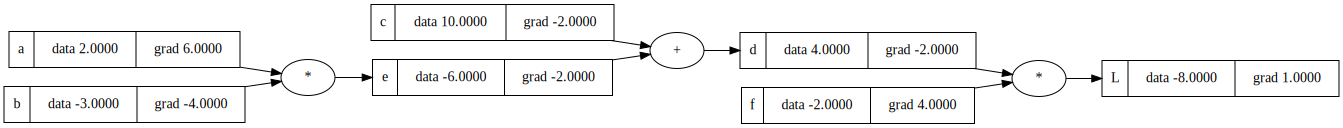

In [24]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label='b')
c = Value(10.0, label= 'c')
e = a * b ; e.label = "e"
d = e + c ; d.label = 'd'
f = Value(-2.0, label='f')
L = d *f ; L.label = 'L'
#gradients
L.grad = 1.0
d.grad = f.data
f.grad = d.data
e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad
b.grad = e.grad * a.data
a.grad = e.grad * b.data

draw_dot(L)